# Функции потерь и оптимизация — простыми словами

Упрощённый разбор темы урока: **как модель учится**, уменьшая ошибку, и **какими способами** мы ищем лучшие параметры.

Разбираем на очень простых примерах:
1. что такое оптимизация и функция потерь;
2. методы **без градиента** (нулевого порядка);
3. **градиентный спуск** и размер шага;
4. **SGD**, momentum, **Adam**;
5. идея **BFGS / L-BFGS** без тяжёлых формул;
6. короткий итог: что когда использовать.

**Нужно:** `numpy`, `matplotlib`.  
Запускайте ячейки **сверху вниз**.


## 0. Словарь терминов

| Термин | Простыми словами |
|--------|------------------|
| **Параметры** | Числа модели (`w`, `b`), которые мы подбираем |
| **Функция потерь (Loss)** | Число «насколько сейчас плохо» |
| **Оптимизация** | Поиск параметров, при которых Loss **минимален** |
| **Градиент** | Стрелка «куда Loss растёт быстрее всего» |
| **Антиградиент** | Стрелка **вниз** — куда идём при обучении |
| **Шаг / learning rate / α / η** | Насколько большой шаг делаем вниз |
| **Итерация** | Один шаг обновления параметров |
| **Сходимость** | Мы всё ближе к хорошему минимуму |
| **Метод нулевого порядка** | Смотрим только на значение Loss, **без** градиента |
| **Метод первого порядка** | Используем градиент (GD, SGD, Adam…) |
| **Метод второго порядка** | Использует ещё «кривизну» (гессиан) — BFGS и похожие |
| **Батч / мини-батч** | Кусочек данных, на котором считаем градиент |
| **Моментум** | «Инерция»: учитываем направление прошлых шагов |
| **Адаптивный шаг** | Разные параметры получают разный размер шага (Adam, Adagrad) |


## 1. Зачем вообще оптимизация?

Обучение модели почти всегда сводится к задаче:

> **Подобрать параметры так, чтобы функция потерь стала как можно меньше.**

### Аналогия

Представь, что Loss — это **высота над землёй**.  
Ты стоишь на холме и хочешь спуститься в **самую низкую точку долины**.

- **где ты стоишь** = текущие параметры модели;
- **высота** = текущий Loss;
- **как спускаешься** = алгоритм оптимизации.

### Мини-пример

Хотим угадать число \(w\), чтобы предсказание \(w \cdot x\) было близко к \(y\).

Пусть один объект: \(x=2\), \(y=10\). Истинный ответ: \(w=5\), потому что \(2\cdot5=10\).

Loss возьмём простой: квадрат ошибки

$$
L(w) = (2w - 10)^2
$$

При \(w=5\) Loss = 0 — идеально.  
При \(w=0\) Loss = 100 — плохо.


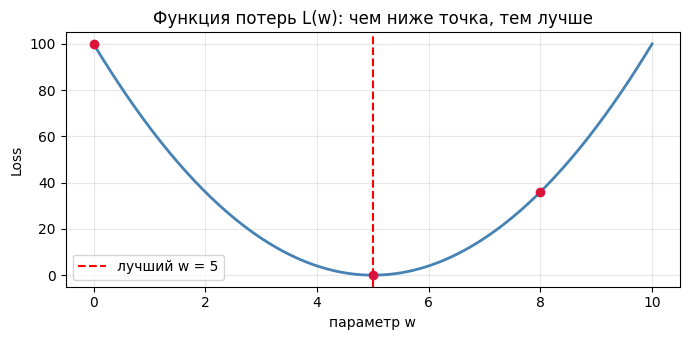

L(0) = 100 — плохо
L(5) = 0 — идеально
L(8) = 36 — ещё ошибаемся


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Loss(w) = (2w - 10)^2 — «чаша», минимум в w=5
ws = np.linspace(0, 10, 200)
loss = (2 * ws - 10) ** 2

plt.figure(figsize=(7, 3.5))
plt.plot(ws, loss, color="steelblue", linewidth=2)
plt.axvline(5, color="red", linestyle="--", label="лучший w = 5")
plt.scatter([0, 5, 8], [(2*0-10)**2, 0, (2*8-10)**2], color="crimson", zorder=5)
plt.title("Функция потерь L(w): чем ниже точка, тем лучше")
plt.xlabel("параметр w")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("L(0) =", (2*0-10)**2, "— плохо")
print("L(5) =", (2*5-10)**2, "— идеально")
print("L(8) =", (2*8-10)**2, "— ещё ошибаемся")


**Вывод.**  
Оптимизация = поиск такого \(w\), где график Loss самый низкий. Дальше смотрим **как** туда дойти.


## 2. Методы нулевого порядка — «пробуем вслепую»

**Нулевой порядок** значит: мы **не считаем градиент**, а только смотрим значение Loss в разных точках.

### Когда так делают
- градиент посчитать сложно/нельзя;
- пространство дискретное (например, выбор гиперпараметра `k` у KNN: 3, 5, 7…);
- хотим простой перебор на маленьком пространстве.

### Аналогия
Ищешь самую низкую точку в комнате **с закрытыми глазами**:  
делаешь шаг туда-сюда, запоминаешь, где было ниже.

### Простой пример
Функция \(f(x)=x^2\). Минимум в \(x=0\).  
Будем случайно пробовать точки и оставлять лучшую.


Лучшая найденная x ≈ 0.1423
Лучшее значение f(x) ≈ 0.0203


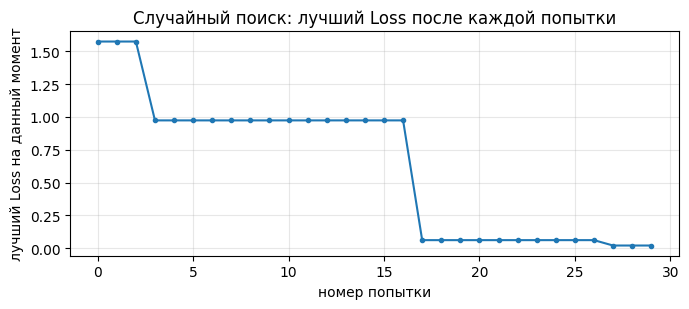

In [2]:
# Метод нулевого порядка: случайный поиск лучшей точки
np.random.seed(42)

def f(x):
    return x ** 2  # минимум в 0

best_x = None
best_f = np.inf
history = []

for i in range(30):  # 30 случайных попыток
    x = np.random.uniform(-5, 5)  # пробуем случайную точку
    val = f(x)
    if val < best_f:  # если стало лучше — запоминаем
        best_x, best_f = x, val
    history.append(best_f)

print("Лучшая найденная x ≈", round(best_x, 4))
print("Лучшее значение f(x) ≈", round(best_f, 4))

plt.figure(figsize=(7, 3.2))
plt.plot(history, marker="o", markersize=3)
plt.title("Случайный поиск: лучший Loss после каждой попытки")
plt.xlabel("номер попытки")
plt.ylabel("лучший Loss на данный момент")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Плюсы:** просто, не нужен градиент.  
**Минусы:** на больших задачах медленно и неточно — поэтому в ML чаще используют градиентные методы.

> В уроке примеры нулевого порядка: подбор гиперпараметров, выбор из конечного множества.


## 3. Градиентный спуск — «шагаем вниз по склону»

### Что такое градиент?
**Градиент** показывает, в какую сторону функция **растёт**.  
Значит, чтобы Loss **уменьшить**, идём в **противоположную** сторону (антиградиент).

### Главная формула

$$
w_{новый} = w_{старый} - \alpha \cdot \frac{dL}{dw}
$$

| Символ | Смысл |
|--------|--------|
| \(w\) | параметр |
| \(\alpha\) (альфа) | размер шага (learning rate) |
| \(dL/dw\) | наклон Loss по \(w\) |

Минус обязателен: градиент смотрит **вверх**, а нам нужно **вниз**.

### Аналогия
Ночь, склон, ничего не видно. Чувствуешь только наклон под ногами → маленький шаг вниз → снова чувствуешь наклон → ещё шаг…


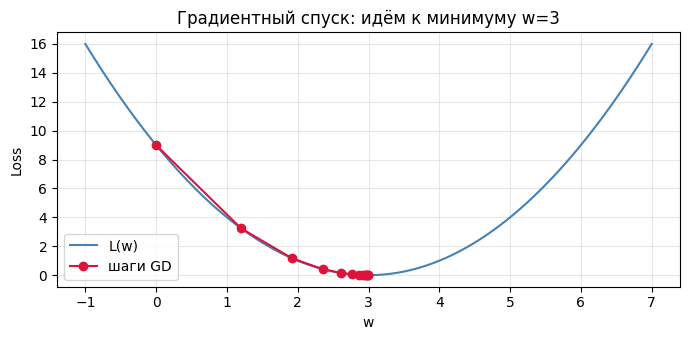

Старт w=0, Loss= 9.0
Финиш w≈ 2.9935 , Loss≈ 4.3e-05


In [3]:
# Градиентный спуск для L(w) = (w - 3)^2
# Производная: dL/dw = 2(w - 3)

def L(w):
    return (w - 3.0) ** 2

def dL(w):
    return 2.0 * (w - 3.0)

def gradient_descent(w0, alpha, steps=12):
    w = w0
    path = [w]
    for _ in range(steps):
        w = w - alpha * dL(w)  # шаг против градиента
        path.append(w)
    return np.array(path)

ws = np.linspace(-1, 7, 200)
path = gradient_descent(w0=0.0, alpha=0.2, steps=12)

plt.figure(figsize=(7, 3.5))
plt.plot(ws, L(ws), color="steelblue", label="L(w)")
plt.plot(path, L(path), "o-", color="crimson", label="шаги GD")
plt.title("Градиентный спуск: идём к минимуму w=3")
plt.xlabel("w"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Старт w=0, Loss=", L(0))
print("Финиш w≈", round(path[-1], 4), ", Loss≈", round(L(path[-1]), 6))


**Вывод.**  
Градиентный спуск не «угадывает» ответ сразу: он **много маленьких шагов** вниз по Loss, пока не подойдёт близко к минимуму.


## 4. Как выбрать шаг α? (learning rate)

Шаг — самый важный «рычаг» градиентного спуска.

| Шаг слишком маленький | Шаг нормальный | Шаг слишком большой |
|-----------------------|----------------|---------------------|
| Ползём вечность | Быстро и стабильно к низу | Перепрыгиваем минимум, можем «улететь» |

### Какие бывают стратегии
1. **Постоянный шаг** — всегда одно и то же α.  
2. **Убывающий шаг** — сначала крупнее, потом мельче: \(\alpha_k = \alpha_0 / \sqrt{k+1}\).  
3. **Подбор по правилам** (Armijo и др.) — автоматически уменьшаем шаг, если Loss не падает достаточно.

На практике в нейросетях часто начинают с разумного lr (например 0.001 для Adam) и при необходимости уменьшают.


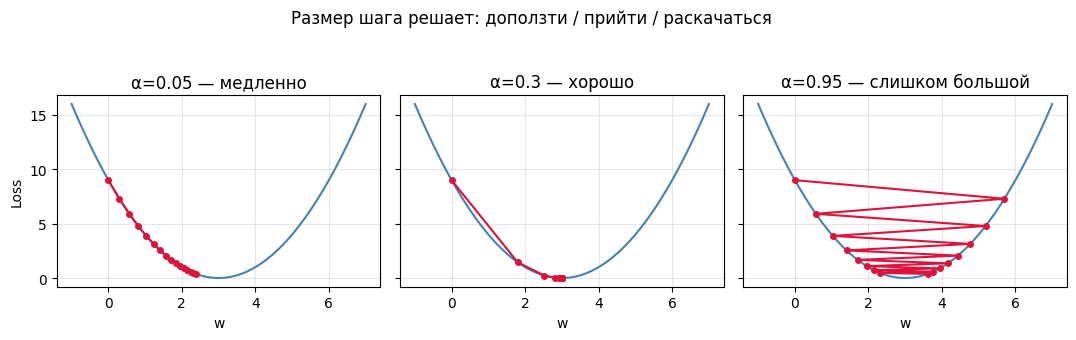

In [4]:
# Один и тот же спуск, разные шаги
ws = np.linspace(-1, 7, 200)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)

configs = [
    (0.05, "α=0.05 — медленно"),
    (0.3, "α=0.3 — хорошо"),
    (0.95, "α=0.95 — слишком большой"),
]

for ax, (alpha, title) in zip(axes, configs):
    path = gradient_descent(0.0, alpha, steps=15)
    ax.plot(ws, L(ws), color="steelblue")
    ax.plot(path, L(path), "o-", color="crimson", markersize=4)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Loss")
plt.suptitle("Размер шага решает: доползти / прийти / раскачаться", y=1.05)
plt.tight_layout()
plt.show()


**Вывод.**  
Если обучение «стоит» — шаг, возможно, слишком мал.  
Если Loss скачет или становится `nan` — шаг слишком велик.


## 5. GD vs SGD — на всех данных или на кусочке?

### Полный градиентный спуск (GD)
Считаем градиент **по всем** объектам → точное направление, но дорого на миллионах строк.

### Стохастический градиентный спуск (SGD)
Считаем градиент по **одному** объекту или **мини-батчу** → быстрее, направление шумнее, но в среднем тоже идём вниз.

### Аналогия
- **GD** — спросить мнение **всего класса**, куда идти.
- **SGD** — спросить **одного/нескольких** учеников и уже шагать.

### Формулы из урока (простыми словами)

**GD:**
$$
w \leftarrow w - \alpha \sum_{i=1}^{N} \nabla L_i(w)
$$
(сумма градиентов по всем примерам)

**SGD / мини-батч:**
$$
w \leftarrow w - \alpha \sum_{i \in \text{батч}} \nabla L_i(w)
$$
(сумма только по случайному кусочку)


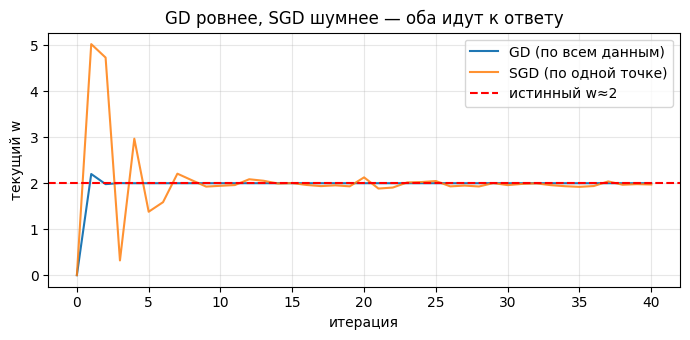

GD финал w≈ 2.0
SGD финал w≈ 1.972


In [5]:
# Игрушечная регрессия: y ≈ 2x
# Сравниваем полный GD и SGD на одних данных

np.random.seed(0)
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = 2.0 * x + np.array([0.1, -0.2, 0.15, -0.1, 0.05])

def mse_grad_full(w):
    # градиент MSE по всем точкам: d/dw mean((w*x - y)^2) = mean(2x(w*x - y))
    return np.mean(2 * x * (w * x - y))

def mse_grad_one(w, i):
    # градиент только по одной точке
    return 2 * x[i] * (w * x[i] - y[i])

def run_gd(w0, alpha, steps=40):
    w = w0
    hist = [w]
    for _ in range(steps):
        w = w - alpha * mse_grad_full(w)
        hist.append(w)
    return np.array(hist)

def run_sgd(w0, alpha, steps=40):
    w = w0
    hist = [w]
    for t in range(steps):
        i = np.random.randint(0, len(x))  # случайный объект
        w = w - alpha * mse_grad_one(w, i)
        hist.append(w)
    return np.array(hist)

gd_path = run_gd(0.0, alpha=0.05)
sgd_path = run_sgd(0.0, alpha=0.05)

plt.figure(figsize=(7, 3.5))
plt.plot(gd_path, label="GD (по всем данным)")
plt.plot(sgd_path, label="SGD (по одной точке)", alpha=0.85)
plt.axhline(2.0, color="red", linestyle="--", label="истинный w≈2")
plt.title("GD ровнее, SGD шумнее — оба идут к ответу")
plt.xlabel("итерация"); plt.ylabel("текущий w")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("GD финал w≈", round(gd_path[-1], 4))
print("SGD финал w≈", round(sgd_path[-1], 4))


**Вывод.**  
В реальном ML почти всегда используют **мини-батч SGD** (или Adam на мини-батчах): компромисс между точностью направления и скоростью.


## 6. Momentum и Нестеров — «шарик с инерцией»

Обычный GD может медленно зигзагами спускаться по узкому оврагу.

**Momentum (импульс)** помнит прошлые шаги: если долго шли в одну сторону, следующий шаг туда же будет увереннее.

### Аналогия
Шарик катится с горки: у него есть **скорость**.  
Он не останавливается мгновенно на каждой кочке.

**Нестеров** — улучшенный вариант: сначала «заглядывает» немного вперёд по инерции, и уже там считает градиент. Часто сходится быстрее.

### Упрощённо
$$
v \leftarrow \beta v + \nabla L(w)
$$
$$
w \leftarrow w - \alpha v
$$

\(\beta\) обычно около 0.9 — насколько сильно помним прошлое.


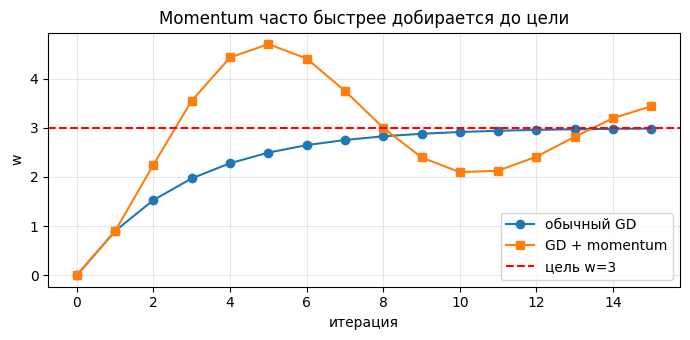

In [6]:
# Сравнение GD и GD+momentum на L(w)=(w-3)^2
# (очень упрощённый 1D-пример только для идеи)

def gd_momentum(w0, alpha=0.15, beta=0.8, steps=15):
    w = w0
    v = 0.0  # «скорость»
    path = [w]
    for _ in range(steps):
        g = dL(w)
        v = beta * v + g  # копим направление
        w = w - alpha * v
        path.append(w)
    return np.array(path)

path_gd = gradient_descent(0.0, alpha=0.15, steps=15)
path_m = gd_momentum(0.0)

plt.figure(figsize=(7, 3.5))
plt.plot(path_gd, "o-", label="обычный GD")
plt.plot(path_m, "s-", label="GD + momentum")
plt.axhline(3.0, color="red", linestyle="--", label="цель w=3")
plt.title("Momentum часто быстрее добирается до цели")
plt.xlabel("итерация"); plt.ylabel("w")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**Вывод.**  
Momentum/Нестеров помогают не «топтаться», используя инерцию прошлых удачных шагов. В PyTorch это `SGD(..., momentum=0.9)`.


## 7. Adagrad и Adam — умный размер шага для каждого параметра

Иногда один параметр нужно двигать сильно, другой — чуть-чуть.  
**Адаптивные** методы сами подкручивают шаг.

### Adagrad
Помнит **все прошлые** градиенты в квадрате.  
Если параметр часто и сильно обновлялся — его будущий шаг становится меньше.

**Минус:** шаг может стать слишком мелким слишком рано.

### Adam (очень популярный)
Комбинация идей:
- как momentum — помнит направление (1-й момент);
- как RMSprop/Adagrad — помнит величину градиентов (2-й момент);
- плюс поправка на старте обучения.

На практике для нейросетей **Adam** часто берут «по умолчанию».

### Аналогия
Не один размер обуви для всех ног, а **свой шаг каждому параметру**.


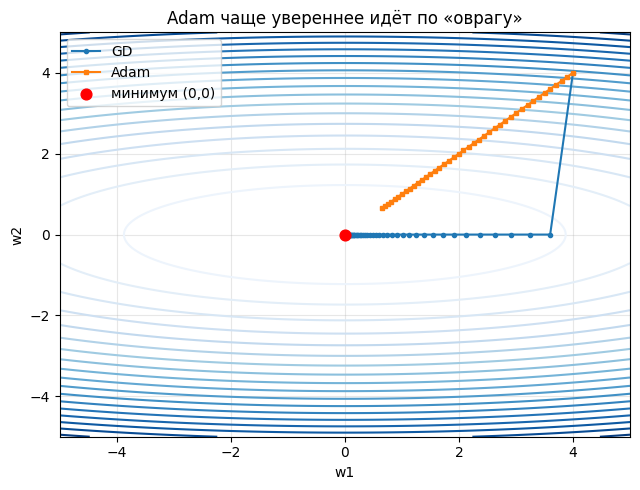

GD финал: [0.0591 0.    ] Loss= 0.003496
Adam финал: [0.6505 0.6505] Loss= 4.655093


In [7]:
# Крошечная иллюстрация идеи Adam vs постоянный шаг
# Функция: L(w1, w2) = w1^2 + 10*w2^2
# По w2 «овраг круче» — обычному GD труднее

def L2(w):
    return w[0] ** 2 + 10 * w[1] ** 2

def grad2(w):
    return np.array([2 * w[0], 20 * w[1]], dtype=float)

def run_gd_2d(steps=40, alpha=0.05):
    w = np.array([4.0, 4.0])
    hist = [w.copy()]
    for _ in range(steps):
        w = w - alpha * grad2(w)
        hist.append(w.copy())
    return np.array(hist)

def run_adam_2d(steps=40, alpha=0.1, b1=0.9, b2=0.999, eps=1e-8):
    w = np.array([4.0, 4.0])
    m = np.zeros(2)  # 1-й момент (как скорость)
    v = np.zeros(2)  # 2-й момент (как накопленный квадрат градиента)
    hist = [w.copy()]
    for t in range(1, steps + 1):
        g = grad2(w)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * (g * g)
        m_hat = m / (1 - b1 ** t)  # поправка в начале
        v_hat = v / (1 - b2 ** t)
        w = w - alpha * m_hat / (np.sqrt(v_hat) + eps)
        hist.append(w.copy())
    return np.array(hist)

gd_h = run_gd_2d()
adam_h = run_adam_2d()

# Рисуем линии уровня и траектории
w1 = np.linspace(-5, 5, 200)
w2 = np.linspace(-5, 5, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = W1 ** 2 + 10 * W2 ** 2

plt.figure(figsize=(6.5, 5))
plt.contour(W1, W2, Z, levels=20, cmap="Blues")
plt.plot(gd_h[:, 0], gd_h[:, 1], "o-", markersize=3, label="GD")
plt.plot(adam_h[:, 0], adam_h[:, 1], "s-", markersize=3, label="Adam")
plt.scatter([0], [0], color="red", s=60, label="минимум (0,0)", zorder=5)
plt.title("Adam чаще увереннее идёт по «оврагу»")
plt.xlabel("w1"); plt.ylabel("w2")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("GD финал:", np.round(gd_h[-1], 4), "Loss=", round(L2(gd_h[-1]), 6))
print("Adam финал:", np.round(adam_h[-1], 4), "Loss=", round(L2(adam_h[-1]), 6))


**Вывод.**  
Adam не всегда идеален, но очень удобен: меньше мучений с ручным подбором одного общего шага для всех параметров.


## 8. BFGS и L-BFGS — «смотрим не только наклон, но и форму чаши»

### Интуиция
Градиент говорит: **куда** вниз.  
**Гессиан** (матрица вторых производных) говорит: **насколько чаша крутая/вытянутая**.

Методы вроде **BFGS** строят приближение этой «формы» и делают более умные шаги. Часто сходятся **быстрее**, чем обычный GD.

### Почему не всегда их используют в нейросетях?
Гессиан огромный: для миллионов параметров матрица не влезает в память.

### L-BFGS (Limited-memory BFGS)
Хранит не всю матрицу, а только **последние m** пар обновлений.  
Памяти нужно гораздо меньше, поэтому метод популярен для «средних» задач оптимизации (в т.ч. в `scipy.optimize`).

| Метод | Идея | Память | Где часто |
|-------|------|--------|-----------|
| GD/SGD/Adam | первый порядок (градиент) | низкая | нейросети, большой ML |
| BFGS | почти второй порядок | высокая \(O(n^2)\) | небольшие/средние задачи |
| L-BFGS | BFGS с короткой памятью | ниже \(O(mn)\) | sklearn/scipy оптимизация |


In [8]:
# Практический крошечный пример: минимизация через scipy
# Сравниваем обычный GD (наш) и L-BFGS из scipy

from scipy.optimize import minimize

def f_vec(w):
    # та же «овражная» функция
    return float(w[0] ** 2 + 10 * w[1] ** 2)

def g_vec(w):
    return np.array([2 * w[0], 20 * w[1]], dtype=float)

w0 = np.array([4.0, 4.0])

# Наш простой GD
gd_hist = run_gd_2d(steps=50, alpha=0.05)

# L-BFGS из scipy
res = minimize(f_vec, w0, jac=g_vec, method="L-BFGS-B", tol=1e-12)

print("GD за 50 шагов: w=", np.round(gd_hist[-1], 6), "Loss=", round(f_vec(gd_hist[-1]), 8))
print("L-BFGS:         w=", np.round(res.x, 6), "Loss=", round(res.fun, 8), "итераций≈", res.nit)
print("\nСмысл: L-BFGS часто доходит точнее/быстрее за меньшее число итераций на гладких задачах.")


GD за 50 шагов: w= [0.020615 0.      ] Loss= 0.00042498
L-BFGS:         w= [-0.  0.] Loss= 0.0 итераций≈ 7

Смысл: L-BFGS часто доходит точнее/быстрее за меньшее число итераций на гладких задачах.


**Вывод.**  
BFGS/L-BFGS — «умные» методы для гладких задач умеренного размера.  
Для огромных нейросетей обычно берут Adam/SGD: они дешевле по памяти и хорошо работают со стохастикой.


## 9. Как это связано с нейросетями (идея без тяжёлого кода)

В нейросети миллионы параметров. Обучение выглядит так:

1. Берём **мини-батч** картинок/строк.  
2. Считаем предсказания.  
3. Считаем **Loss** (например Cross Entropy).  
4. Через `backward()` получаем градиенты всех весов.  
5. Оптимизатор (**SGD / Adam / Adagrad…**) обновляет веса.  
6. Повторяем тысячи раз.

В исходном ноутбуке урока это показано на MNIST: сравнивают SGD, SGD+momentum, Adam, Adagrad.

**Что обычно видно на практике:**
- чистый SGD — медленнее стартует;
- momentum — быстрее;
- **Adam** — часто самый удобный старт;
- Adagrad — тоже адаптивный, но иногда рано «сдувает» шаг.


## 10. Большая шпаргалка

| Метод | Смотрит на… | Простыми словами | Когда уместен |
|-------|-------------|------------------|---------------|
| Случайный поиск / Grid | только Loss | пробуем варианты | гиперпараметры, дискретные выборы |
| GD | полный градиент | точный шаг вниз | маленькие данные |
| SGD / мини-батч | кусочек данных | быстрый шумный спуск | большие данные |
| Momentum / Nesterov | градиент + инерция | шарик с разгоном | ускорить SGD |
| Adagrad | градиент + история силы | свой шаг каждому параметру | редкие признаки |
| Adam | momentum + адаптивный шаг | «универсальный» оптимизатор | нейросети по умолчанию |
| BFGS | градиент + форма чаши | умные крупные шаги | небольшие гладкие задачи |
| L-BFGS | то же, но мало памяти | почти BFGS без огромной матрицы | scipy/sklearn, средние задачи |


## 11. Итог простыми словами

1. **Loss** говорит, насколько модель сейчас плоха.  
2. **Оптимизация** — спуск к маленькому Loss.  
3. **Градиент** показывает направление вверх; мы идём **против** него.  
4. **Шаг α** нельзя выбрать «с потолка»: слишком мал — медленно, слишком велик — разнос.  
5. На больших данных считаем градиент не по всем объектам, а по **батчу** (SGD).  
6. **Momentum/Adam** добавляют инерцию и/или адаптивный шаг — обычно ускоряют обучение.  
7. **BFGS/L-BFGS** умнее используют форму функции, но для гигантских нейросетей тяжелы.  
8. Практический старт: для классического ML часто хватает готовых солверов; для нейросетей чаще начинают с **Adam**.

> Главная картинка в голове: *мы стоим на горе ошибки и учимся быстрее спускаться в долину правильных параметров.*
